# Notebook 15：运动规划基础 — C-空间、图搜索与势场法

## 1. 本节在知识体系中的位置

```
NB05 FK ──→ NB15 运动规划基础 ──→ NB16 采样规划
                 │
                 ├── C-空间：将机器人简化为点
                 ├── 图搜索：Dijkstra / A*
                 └── 势场法：梯度下降
```

运动规划是机器人的"大脑"：有一张已知地图，如何找到一条从起点到终点且不碰撞任何障碍物的路径？

## 2. 学习目标

- ⭐ 理解 C-空间（Configuration Space）的概念和意义
- ⭐ 掌握 Dijkstra 算法（全局最短路径）
- ⭐ 掌握 A* 算法（启发式搜索）及其最优性条件
- ⭐ 理解势场法的引力/斥力设计和局部极小值问题
- 📖 高维 C-space 的维度灾难

## 3. C-空间 ⭐

### 3.1 核心思想

- 在机器人工作空间（笛卡尔空间）中，机器人有体积和形状 → 碰撞检测复杂
- 将机器人"坍缩"成一个点，把障碍物相应地**膨胀**（Minkowski 和）→ 这就是 C-空间
- 在 C-空间中，"点机器人"在自由空间 $\mathcal{C}_{free}$ 中移动

$$\mathcal{C} = \mathcal{C}_{free} \cup \mathcal{C}_{obs}$$

### 3.2 维度

对于 $n$-DOF 机械臂，$\mathcal{C} \subseteq \mathbb{R}^n$。2R 臂的 C-空间是 $[-\pi, \pi]^2$（一个环面）。

## 4. A* 算法 ⭐

### 4.1 算法流程

A* 是 Dijkstra 的推广。维护两个集合：Open（待探索）、Closed（已探索）：

1. 将起点加入 Open，$g(start)=0$，$f(start)=h(start)$
2. 循环：从 Open 取 $f(n)$ 最小的节点 $n$
3. 若 $n$ 是终点 → 回溯路径，返回
4. 将 $n$ 移入 Closed
5. 对 $n$ 的每个邻居 $m$：
   - $g_{new} = g(n) + cost(n,m)$
   - 若 $g_{new} < g(m)$：更新 $g(m)$，$f(m) = g(m) + h(m)$，将 $m$ 加入 Open
6. Open 为空 → 无可行路径

$f(n) = g(n) + h(n)$ = 已走过代价 + 预估剩余代价

### 4.2 启发函数

| 启发函数 | $h(n)$ | 性质 |
|----------|--------|------|
| 零启发 | $h=0$ | Dijkstra（保证最短路但搜索最多） |
| 曼哈顿 | $\lvert\Delta x\rvert + \lvert\Delta y\rvert$ | 4-连通网格 |
| 欧氏 | $\sqrt{(\Delta x)^2 + (\Delta y)^2}$ | 8-连通 + admissible |
| 对角线 | $\max(\lvert\Delta x\rvert, \lvert\Delta y\rvert)$ | 8-连通网格 |

- **Admissible**：$h(n) \leq h^*(n)$（不高估真实代价）→ A* 保证最优解
- **Consistent**：$h(n) \leq cost(n,m) + h(m)$（三角不等式）→ 更高效（不需 reopen）

## 5. 势场法

### 5.1 基本思想

构造势能函数 $U(\mathbf{q}) = U_{att}(\mathbf{q}) + U_{rep}(\mathbf{q})$：
- **引力势场**：$U_{att} = \frac{1}{2}k_{att} \|\mathbf{q} - \mathbf{q}_{goal}\|^2$ → $\mathbf{F}_{att} = -k_{att}(\mathbf{q} - \mathbf{q}_{goal})$
- **斥力势场**：$U_{rep} = \frac{1}{2}k_{rep}(1/\rho - 1/\rho_0)^2$（仅在 $\rho < \rho_0$ 时有效）

机器人沿势能梯度下降：$\dot{\mathbf{q}} = -\nabla U(\mathbf{q})$

### 5.2 局部极小值

势场法最大的问题是**局部极小值**——机器人可能被困在非目标的势能洼地中。
解决方法：随机扰动、导航函数、或改用图搜索/采样规划。

## 6. Python 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sys
sys.path.insert(0, '..')
from src.robotics_learning.planning import (
    create_grid_map, dijkstra, astar, potential_field_plan
)
%matplotlib inline
print("✅ 导入完成")

✅ 导入完成


### 6.1 A* vs Dijkstra

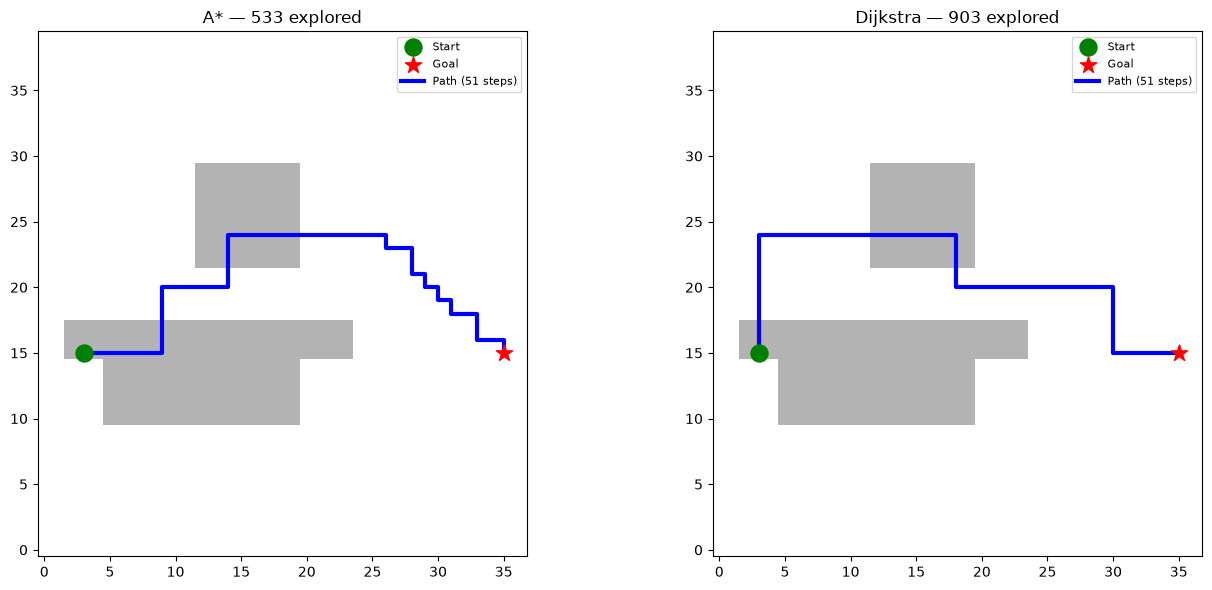

A* explored 533 nodes, Dijkstra explored 903 nodes
Ratio: 59% — A* is much more efficient!


In [2]:
grid = create_grid_map(40, 30, [(10,5,5,15), (22,12,8,8), (15,2,3,22)])

start, goal = (3, 15), (35, 15)
path_astar, info_a = astar(grid, start, goal)
path_dijk, info_d = dijkstra(grid, start, goal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, path, explored, title in [
    (axes[0], path_astar, info_a['explored'], f'A* — {len(info_a["explored"])} explored'),
    (axes[1], path_dijk, info_d['explored'], f'Dijkstra — {len(info_d["explored"])} explored')
]:
    ax.imshow(grid.T, origin='lower', cmap='gray_r', alpha=0.3)
    ax.scatter(*start, c='green', s=150, marker='o', label='Start', zorder=5)
    ax.scatter(*goal, c='red', s=150, marker='*', label='Goal', zorder=5)
    if path:
        path_arr = np.array(path)
        ax.plot(path_arr[:, 0], path_arr[:, 1], 'b-', linewidth=3, label=f'Path ({len(path)} steps)')
    ax.set_title(title); ax.legend(fontsize=8); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../outputs/15_astar_vs_dijkstra.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"A* explored {len(info_a['explored'])} nodes, Dijkstra explored {len(info_d['explored'])} nodes")
print(f"Ratio: {len(info_a['explored'])/len(info_d['explored']):.0%} — A* is much more efficient!")

### 6.2 势场法演示

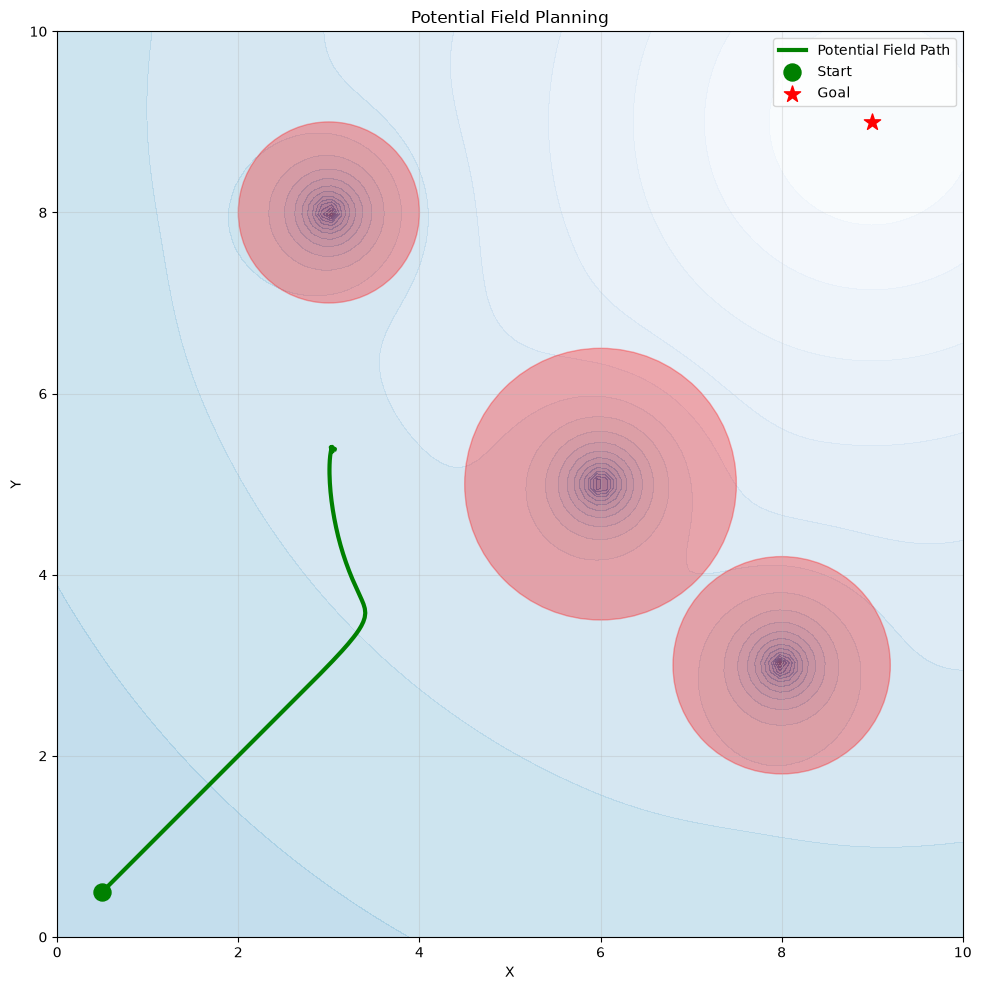

In [3]:
obstacles = [
    {'center': np.array([6.0, 5.0]), 'radius': 1.5},
    {'center': np.array([3.0, 8.0]), 'radius': 1.0},
    {'center': np.array([8.0, 3.0]), 'radius': 1.2},
]

path_pf, _ = potential_field_plan(
    np.array([0.5, 0.5]), np.array([9.0, 9.0]),
    obstacles, k_att=1.0, k_rep=50.0, rho_0=2.5
)
path_pf = np.array(path_pf)

fig, ax = plt.subplots(figsize=(10, 10))
# 势场背景
x_grid = np.linspace(0, 10, 100); y_grid = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x_grid, y_grid)
U_total = np.zeros_like(X)
for i in range(len(x_grid)):
    for j in range(len(y_grid)):
        q = np.array([X[j,i], Y[j,i]])
        U_att = 0.5 * 1.0 * np.linalg.norm(q - np.array([9.0, 9.0]))**2
        U_rep = 0
        for obs in obstacles:
            d = np.linalg.norm(q - obs['center'])
            if d < 2.5 and d > 1e-3:
                U_rep += 0.5 * 50 * (1/d - 1/2.5)**2
        U_total[j,i] = U_att + U_rep

ax.contourf(X, Y, np.log(U_total + 1), levels=20, cmap='Blues', alpha=0.5)
for obs in obstacles:
    circle = plt.Circle(obs['center'], obs['radius'], color='red', alpha=0.3)
    ax.add_patch(circle)
ax.plot(path_pf[:, 0], path_pf[:, 1], 'g-', linewidth=3, label='Potential Field Path')
ax.scatter(0.5, 0.5, c='green', s=150, marker='o', label='Start')
ax.scatter(9, 9, c='red', s=150, marker='*', label='Goal')
ax.set_xlim([0, 10]); ax.set_ylim([0, 10])
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Potential Field Planning')
ax.set_aspect('equal'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/15_potential_field.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. 练习题

### 概念题
1. A* 的 admissible 条件是什么？为什么不满足时不能保证最优解？
2. 势场法的局部极小值是怎么产生的？

### 编程题
1. 实现 A* 的 8-连通版本（带对角线代价 $\sqrt{2}$）。
2. 对 2R 臂在障碍物环境中的 C-space 做路径规划。

> 答案见 `solutions/15_solutions.ipynb`

## 8. 本节总结

| 算法 | 完备性 | 最优性 | 适用维度 |
|------|:------:|:------:|:--------:|
| Dijkstra | ✓ | ✓ (给定分辨率) | 低维(~3) |
| A* | ✓ | ✓ (admissible h) | 低维(~3) |
| 势场法 | ✗ (局部极小) | ✗ | 任意(但局部) |
| 采样方法 | 概率完备 | 渐进最优(RRT*) | 高维 |